## 6-DoF Lander SCP

Imports

In [1]:
# Basic imports
import importlib
import numpy                as np
import matplotlib.pyplot    as plt
import pandas               as pd
import copy

# Trajopt imports --> pip install -e ~/ACL/trajopt
import trajopt; importlib.reload(trajopt)
import trajopt.core.modules.method.scp              as scp
import trajopt.core.Trajopt                         as traj
import trajopt.core.modules.utils.config_loader                  as cfg
import trajopt.core.modules.utils.tools                          as tools
import trajopt.analysis.default_analysis            as default_analysis
import trajopt.analysis.statistics                  as stats
import trajopt.core.modules.analysis.monte_carlo    as mc
import trajopt.core.modules.analysis.standalone     as standalone

from trajopt.analysis.trajplots import *

np.random.seed(0)  # for reproducibility


In [2]:
example_name = "lander_6dof"
method_name = "standard"
config  = cfg.load_configs(example_name)

# create problem instance
trajopt_obj = traj.Trajopt(config)

# run SCP
trajopt_obj = scp.run_scp(trajopt_obj)

# store scenario data struct for plotting
scenario_data = standalone.run_standalone_analysis(trajopt_obj, method_name)

constraints:
  0: equality_bc
  1: equality_bc
  2: equality_bc
  3: box
  4: axis_angle_cone
  5: axis_angle_cone
  6: max_norm_cone
  7: quaternion_cone
  8: nonconvex_inequality
constraint_ids: 

{'nodal': {'all': [0, 1, 2, 3, 4, 5, 6, 7, 8],
           'axis_angle_cone': [4, 5],
           'box': [3],
           'equality_bc': [0, 1, 2],
           'max_norm_cone': [6],
           'nonconvex_inequality': [8],
           'quaternion_cone': [7]}}
costs:
  0: time
cost_ids: 

{'all': [0], 'time': [0]}
scales: 
d: 1.0000, t: 1.0000, m: 1.0000, v: 1.0000, a: 1.0000, f: 1.0000, ang: 57.2958, angv: 57.2958, none: 1.0000
Cost initial: 0.0
total number of parameters: 15388
--------------------------------------------------------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------------------------------------------------
  Iteration |  Pr

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


     01     |    01304.3   |   0013.9  |   0709.5   |   -3.1    |      -12.0      |    -12.0    |     -00.3   |    optimal    |   4.50   |   0.0
     02     |    00008.2   |   0014.4  |   0673.4   |   +0.4    |      -12.0      |    -12.0    |     -00.3   |    optimal    |   4.03   |   0.0
     03     |    00008.0   |   0012.8  |   0665.4   |   +0.2    |      -12.0      |    -12.0    |     -00.4   |    optimal    |   3.90   |   0.0
     04     |    00007.9   |   0012.9  |   0676.0   |   -0.2    |      -12.0      |    -12.0    |     -00.6   |    optimal    |   4.09   |   0.0
     05     |    00007.8   |   0013.7  |   0660.7   |   -0.0    |      -12.0      |    -12.0    |     -01.1   |    optimal    |   4.39   |   0.0
     06     |    00007.7   |   0013.6  |   0661.3   |   -0.5    |      -12.0      |    -12.0    |     -01.6   |    optimal    |   4.83   |   0.0
     07     |    00007.8   |   0014.4  |   0589.1   |   -0.7    |      -12.0      |    -12.0    |     -03.4   |    optimal    |   

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


     09     |    00007.9   |   0014.6  |   0686.6   |   -2.4    |      -12.0      |    -12.0    |     -03.9   |    optimal_inaccurate    |   5.01   |   0.0
     10     |    00008.0   |   0013.6  |   0654.9   |   -2.4    |      -12.0      |    -12.0    |     -04.3   |    optimal    |   5.01   |   0.0
     11     |    00008.0   |   0014.2  |   0654.0   |   -2.4    |      -12.0      |    -12.0    |     -04.0   |    optimal    |   5.01   |   0.0
     12     |    00007.9   |   0014.4  |   0656.8   |   -2.4    |      -12.0      |    -12.0    |     -04.6   |    optimal_inaccurate    |   5.00   |   0.0
     13     |    00008.0   |   0014.6  |   0600.6   |   -2.4    |      -12.0      |    -12.0    |     -04.5   |    optimal    |   5.00   |   0.0
     14     |    00007.7   |   0014.9  |   0681.3   |   -2.4    |      -12.0      |    -12.0    |     -04.6   |    optimal    |   5.00   |   0.0
     15     |    00007.8   |   0015.1  |   0855.6   |   -2.4    |      -12.0      |    -12.0    |     -04.8 

In [3]:
# Direction Cosine Matrix Function
def DCM(q): 
    return np.array(
        [
            [
                1 - 2 * (q[2] ** 2 + q[3] ** 2),
                2 * (q[1] * q[2] + q[0] * q[3]),
                2 * (q[1] * q[3] - q[0] * q[2]),
            ],
            [
                2 * (q[1] * q[2] - q[0] * q[3]),
                1 - 2 * (q[1] ** 2 + q[3] ** 2),
                2 * (q[2] * q[3] + q[0] * q[1]),
            ],
            [
                2 * (q[1] * q[3] + q[0] * q[2]),
                2 * (q[2] * q[3] - q[0] * q[1]),
                1 - 2 * (q[1] ** 2 + q[2] ** 2),
            ],
        ]
    )


<Figure size 640x480 with 0 Axes>

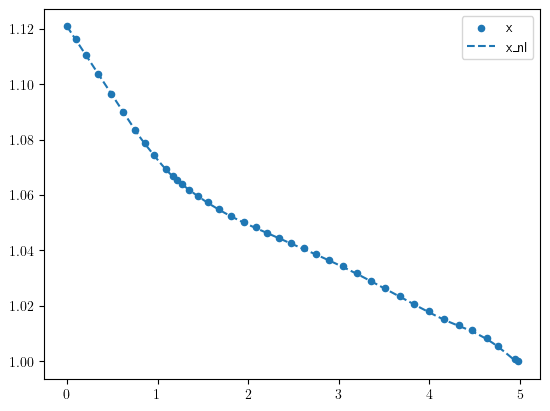

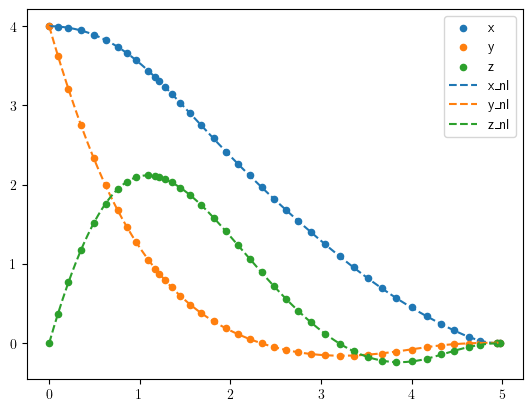

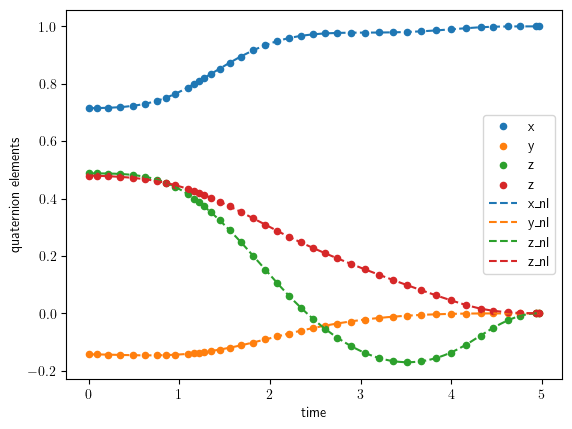

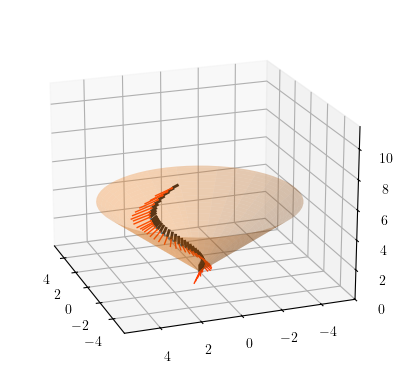

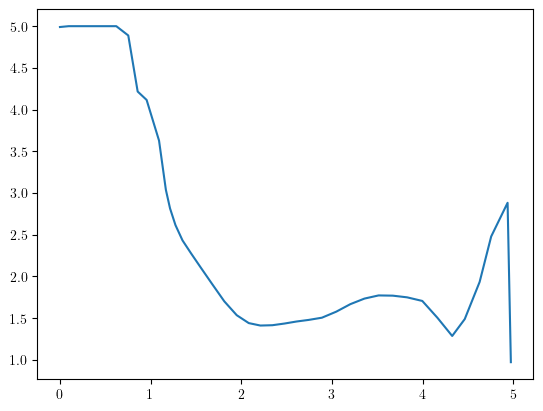

<Figure size 640x480 with 0 Axes>

In [4]:
# Direction Cosine Matrix Function
def DCM(q): 
    return np.array(
        [
            [
                1 - 2 * (q[2] ** 2 + q[3] ** 2),
                2 * (q[1] * q[2] + q[0] * q[3]),
                2 * (q[1] * q[3] - q[0] * q[2]),
            ],
            [
                2 * (q[1] * q[2] - q[0] * q[3]),
                1 - 2 * (q[1] ** 2 + q[3] ** 2),
                2 * (q[2] * q[3] + q[0] * q[1]),
            ],
            [
                2 * (q[1] * q[3] + q[0] * q[2]),
                2 * (q[2] * q[3] - q[0] * q[1]),
                1 - 2 * (q[1] ** 2 + q[2] ** 2),
            ],
        ]
    )

import matplotlib.pyplot as plt



# ======= UNCOMMENT THIS TO ENABLE INTERACTIVE PLOTS =======
# %matplotlib ipympl
# ==========================================================


matplotlib.rcParams['axes3d.mouserotationstyle'] = 'azel'

soln = scenario_data['standard']['mc_data'][0]['iters'][-1]

t_opt = soln['t_opt']
z_opt = soln['z_opt']
nu_opt = soln['nu_opt']

t_nl = soln['t_nl']
z_nl = soln['z_nl']
nu_nl = soln['nu_nl']

DCMs = np.empty((trajopt_obj.method.N, 3, 3))
u_vecs = np.empty_like(nu_opt[:, :trajopt_obj.problem.m])
rt_I = np.zeros((trajopt_obj.method.N, 3))
body_vecs = np.zeros((trajopt_obj.method.N, 3))

veh = trajopt_obj.problem.mission.vehicle
rt = np.array([veh["rt1"], veh["rt2"], veh["rt3"]])

for i in range(trajopt_obj.method.N):
    DCMs[i] = DCM(z_opt[i, 7:11])

    u_vecs[i] = 0.3* DCMs[i].T @ nu_opt[i, :trajopt_obj.problem.m]
    rt_I[i] = DCMs[i].T @ rt
    body_vecs[i] = 0.5 * DCMs[i].T @ np.array([1, 0, 0])


plt.figure()
plt.scatter(t_opt, z_opt[:, 0], label='x', s=20)
plt.plot(t_nl, z_nl[:, 0], label='x_nl', linestyle='--')
plt.legend()

# # position plots
plt.figure()
plt.scatter(t_opt, z_opt[:, 1], label='x', s=20)
plt.scatter(t_opt, z_opt[:, 2], label='y', s=20)
plt.scatter(t_opt, z_opt[:, 3], label='z', s=20)

plt.plot(t_nl, z_nl[:, 1], label='x_nl', linestyle='--')
plt.plot(t_nl, z_nl[:, 2], label='y_nl', linestyle='--')
plt.plot(t_nl, z_nl[:, 3], label='z_nl', linestyle='--')
plt.legend()

plt.figure()
plt.scatter(t_opt, z_opt[:, 7], label='x', s=20)
plt.scatter(t_opt, z_opt[:, 8], label='y', s=20)
plt.scatter(t_opt, z_opt[:, 9], label='z', s=20)
plt.scatter(t_opt, z_opt[:, 10], label='z', s=20)

plt.plot(t_nl, z_nl[:, 7], label='x_nl', linestyle='--')
plt.plot(t_nl, z_nl[:, 8], label='y_nl', linestyle='--')
plt.plot(t_nl, z_nl[:, 9], label='z_nl', linestyle='--')
plt.plot(t_nl, z_nl[:, 10], label='z_nl', linestyle='--')
plt.legend()
plt.ylabel("quaternion elements")
plt.xlabel("time")

skip = 1

# 3D position plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(z_nl[:, 2], z_nl[:, 3], z_nl[:, 1], linestyle='--')
ax.quiver3D(z_opt[::skip, 2], z_opt[::skip, 3], z_opt[::skip, 1], body_vecs[::skip, 1], body_vecs[::skip, 2], body_vecs[::skip, 0],
            normalize=False,
            arrow_length_ratio=0,
            color=(0.1, 0.1, 0.1),
            linewidth=2.0)

ax.quiver3D(z_opt[::skip, 2] - u_vecs[::skip, 1],
             z_opt[::skip, 3] - u_vecs[::skip, 2],
             z_opt[::skip, 1] - u_vecs[::skip, 0],
            u_vecs[::skip, 1], u_vecs[::skip, 2], u_vecs[::skip, 0],
            normalize=False,
            arrow_length_ratio=0.1,
            color=(1, 60/255, 0),
            linewidth=1)

#glideslope cone plot

# Parameters
height = 5                     # cone length along +x
alpha = np.deg2rad(45)         # half-angle of cone (degrees -> radians)
num_points = 60

# Create mesh
x = np.linspace(0, height, num_points)
theta = np.linspace(0, 2*np.pi, num_points)

X, THETA = np.meshgrid(x, theta)

# Radius grows linearly with x
R = X * np.tan(alpha)

# Convert to Cartesian coords
Y = R * np.cos(THETA)
Z = R * np.sin(THETA)

ax.plot_surface(Y, Z, X, alpha=0.3, edgecolor='none')

# PLOT ASPECT RATIO FIXING (NEEDS TO BE DONE MANUALLY FOR 3D PLOTS :( )

# fix aspect ratio of 3d plot
x_lim = ax.get_xlim3d()
y_lim = ax.get_ylim3d()
z_lim = ax.get_zlim3d()

max_lim = max(abs(x_lim[1] - x_lim[0]), abs(y_lim[1] - y_lim[0]), abs(z_lim[1] - z_lim[0]))
x_mid = sum(x_lim) * 0.5
y_mid = sum(y_lim) * 0.5

ax.set_xlim3d([x_mid - max_lim * 0.5, x_mid + max_lim * 0.5])
ax.set_ylim3d([y_mid - max_lim * 0.5, y_mid + max_lim * 0.5])
ax.set_zlim3d([0, max_lim])

ax.view_init(elev=20, azim=160)

plt.figure()
plt.plot(t_opt, np.linalg.norm(nu_opt[:, :3], axis=1))

plt.figure()



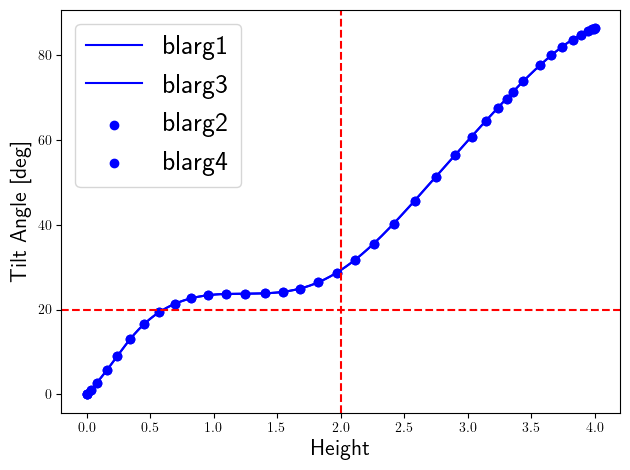

In [5]:

PENS = {};
PENS['CT'] = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
PENS['NONCT'] = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};

tilt_angles_nl = np.zeros(20 * trajopt_obj.method.N)
for i in range(20 * trajopt_obj.method.N):
    tilt_angles_nl[i] = np.rad2deg(np.arccos(1 - 2 * np.sum(z_nl[i, 9:11] ** 2)))

tilt_angles_opt = np.zeros(trajopt_obj.method.N)
for i in range(trajopt_obj.method.N):
    tilt_angles_opt[i] = np.rad2deg(np.arccos(1 - 2 * np.sum(z_opt[i, 9:11] ** 2)))


penn = PENS['CT']
lrgba = penn['lrgba']; msz = penn['msz']; msty = penn['msty']; lw = penn['lw']; ls = penn['ls'];
h1 = plt.plot(z_nl[:, 1], tilt_angles_nl,linestyle=ls,color=lrgba,label='blarg1')[0]
h2 = plt.scatter(z_opt[:, 1], tilt_angles_opt,color=lrgba,label='blarg2')

penn = PENS['NONCT']
lrgba = penn['lrgba']; msz = penn['msz']; msty = penn['msty']; lw = penn['lw']; ls = penn['ls'];
h3 = plt.plot(z_nl[:, 1], tilt_angles_nl,linestyle=ls,color=lrgba,label='blarg3')[0]
h4 = plt.scatter(z_opt[:, 1], tilt_angles_opt,color=lrgba,label='blarg4')


plt.axvline(x=2.0, color='r', linestyle='--')
plt.axhline(y=20.0, color='r', linestyle='--')

labels = ['blarg1','blarg3','blarg2','blarg4']
handles = [h1,h3,h2,h4]
plt.legend(handles,labels,fontsize=20)


# plt.title("Tilt angle vs height")
plt.xlabel("Height", fontsize=16)
plt.ylabel("Tilt Angle [deg]",fontsize=16)
plt.tight_layout()
plt.show()


        








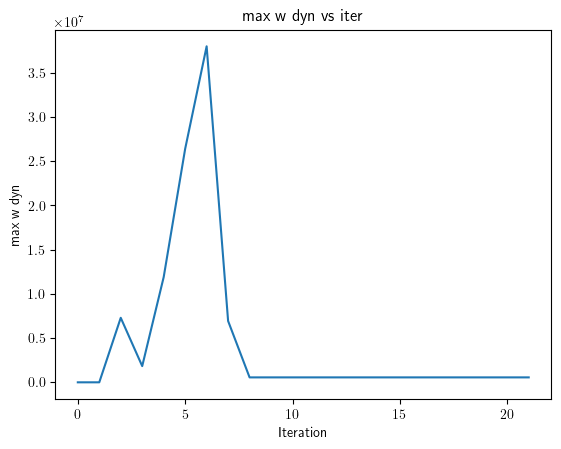

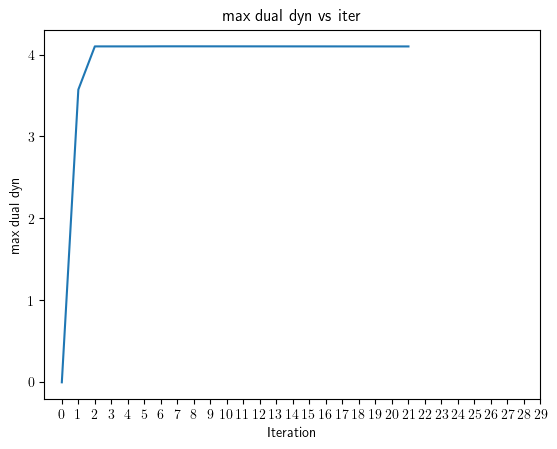

In [6]:
iters = scenario_data['standard']['mc_data'][0]['iters']

max_W_dyn = [iter["weights"]["W_dyn"].max() for iter in iters]
plt.figure()
plt.plot(max_W_dyn)
plt.xlabel("Iteration")
plt.ylabel("max w dyn")
plt.title("max w dyn vs iter")
plt.show()

max_dual_dyn = [iter["weights"]["dual_dyn"].max() for iter in iters]
plt.figure()
plt.plot(max_dual_dyn)
plt.xlabel("Iteration")
plt.ylabel("max dual dyn")
plt.title("max dual dyn vs iter")
plt.xticks(range(0, 30))
plt.show()

